In [1]:
import numpy as np
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%reload_ext autoreload
%autoreload 2
import pygem_eb.input as eb_prms

In [36]:
start = eb_prms.startdate
end = eb_prms.enddate
dates = pd.date_range(start,end,freq='H')
df = pd.read_csv('/home/claire/research/climate_data/AWS/Gulkana/LVL2/gulkana1725_hourly_LVL2.csv')
data_start = pd.to_datetime(df.local_time[0])
data_end = pd.to_datetime(df.local_time.to_numpy()[-1])
df = df.set_index(pd.date_range(data_start,data_end,freq='H'))
df = df.loc[start:end]
vars = df.columns
if 'Precip_Stage_Incremental' in vars:
    df.Precip_Weighing_Incremental.fillna(df.Precip_Stage_Incremental*1.48, inplace=True)
df = df.interpolate('time')
AWS_temp = df['site_temp_USGS'].to_numpy() + eb_prms.lapserate*(eb_prms.bin_elev[1] - 1725)
AWS_precip = np.nan_to_num(df['Precip_Weighing_Incremental'].to_numpy())*(1+eb_prms.precgrad*(eb_prms.bin_elev[1] - 1725)) / 1000 
# original precip data is in mm w.e. so need to convert to m (/1000)
prec = np.nan_to_num(df['Precip_Weighing_Incremental'].to_numpy())
print(np.mean(prec),np.max(prec))

0.14227333206614712 13.0


In [37]:
ds = xr.open_dataset('/home/claire/research/Output/EB/climateds.nc').isel(bin=1)
ds = ds.sel(time=xr.DataArray(dates,dims=['time']))
GCM_elev = 1329.3921
GCM_temp = ds['bin_temp'].values + eb_prms.lapserate*(GCM_elev - eb_prms.bin_elev[1])
GCM_precip = (ds['bin_prec'].values * (1+eb_prms.precgrad*(GCM_elev - eb_prms.bin_elev[1]))) # total hourly precip in m

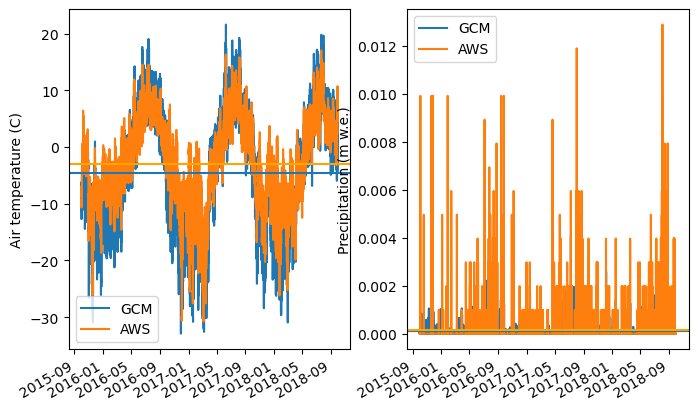

In [38]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(8,5))
ax1.plot(dates,GCM_temp,label='GCM')
ax1.plot(dates,AWS_temp,label='AWS')
ax2.plot(dates,GCM_precip,label='GCM')
ax2.plot(dates,AWS_precip,label='AWS')
ax1.axhline(np.mean(GCM_temp))
ax1.axhline(np.mean(AWS_temp),color='orange')
ax2.axhline(np.mean(GCM_precip))
ax2.axhline(np.mean(AWS_precip),color='orange')
ax1.set_ylabel('Air temperature (C)')
ax2.set_ylabel('Precipitation (m w.e.)')
ax1.legend()
ax2.legend()
plt.gcf().autofmt_xdate()
plt.show()

In [ ]:
df = pd.read_csv('/home/claire/research/climate_data/AWS/Gulkana/LVL2/gulkana1725_hourly_LVL2.csv')
data_start = pd.to_datetime(df.local_time[0])
data_end = pd.to_datetime(df.local_time.to_numpy()[-1])
df = df.set_index(pd.date_range(data_start,data_end,freq='H'))
vars = df.columns
if 'Precip_Stage_Incremental' in vars:
    df.Precip_Weighing_Incremental.fillna(df.Precip_Stage_Incremental*1.48, inplace=True)
AWS_df = df.interpolate('time')